In [17]:
# Data loading
import pickle
# Data manipulation
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
# Random Forest Regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math
# Visualizations
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
with open("cluj_prices_lm.pkl", "rb") as f:
    data = pickle.load(f)
data.shape

(161, 11)

In [19]:
data.head()

,price_euro,rooms,size,bathrooms,terrace,pass_through,finished,height_pos,neighbourhood,year_built,zone
0,133425,2,53.0,1,1,False,not finished,0.17,Intre Lacuri,2024,other
1,168675,3,67.0,2,2,False,not finished,0.17,Intre Lacuri,2024,other
2,177825,3,69.0,2,2,False,not finished,0.17,Intre Lacuri,2024,other
3,168675,3,67.0,2,2,False,not finished,0.17,Gheorgheni,2024,other
4,133725,2,53.0,1,0,True,not finished,0.17,Intre Lacuri,2024,other


In [20]:
data.dtypes

price_euro         int64
rooms              int64
size             float64
bathrooms          int64
terrace            int64
pass_through        bool
finished          object
height_pos       float64
neighbourhood     object
year_built         int32
zone              object
dtype: object

In [21]:
data.neighbourhood = data.neighbourhood.str. lower()
data.finished = data.finished.str.lower()
data.zone = data.zone.str.lower()

In [22]:
le = LabelEncoder()
data.neighbourhood = le.fit_transform(data.neighbourhood)
data.finished = le.fit_transform(data.finished)
data.zone = le.fit_transform(data.zone)

In [23]:
data.neighbourhood = data.neighbourhood.astype("category")
data.finished = data.finished.astype("category")
data.zone = data.zone.astype("category")

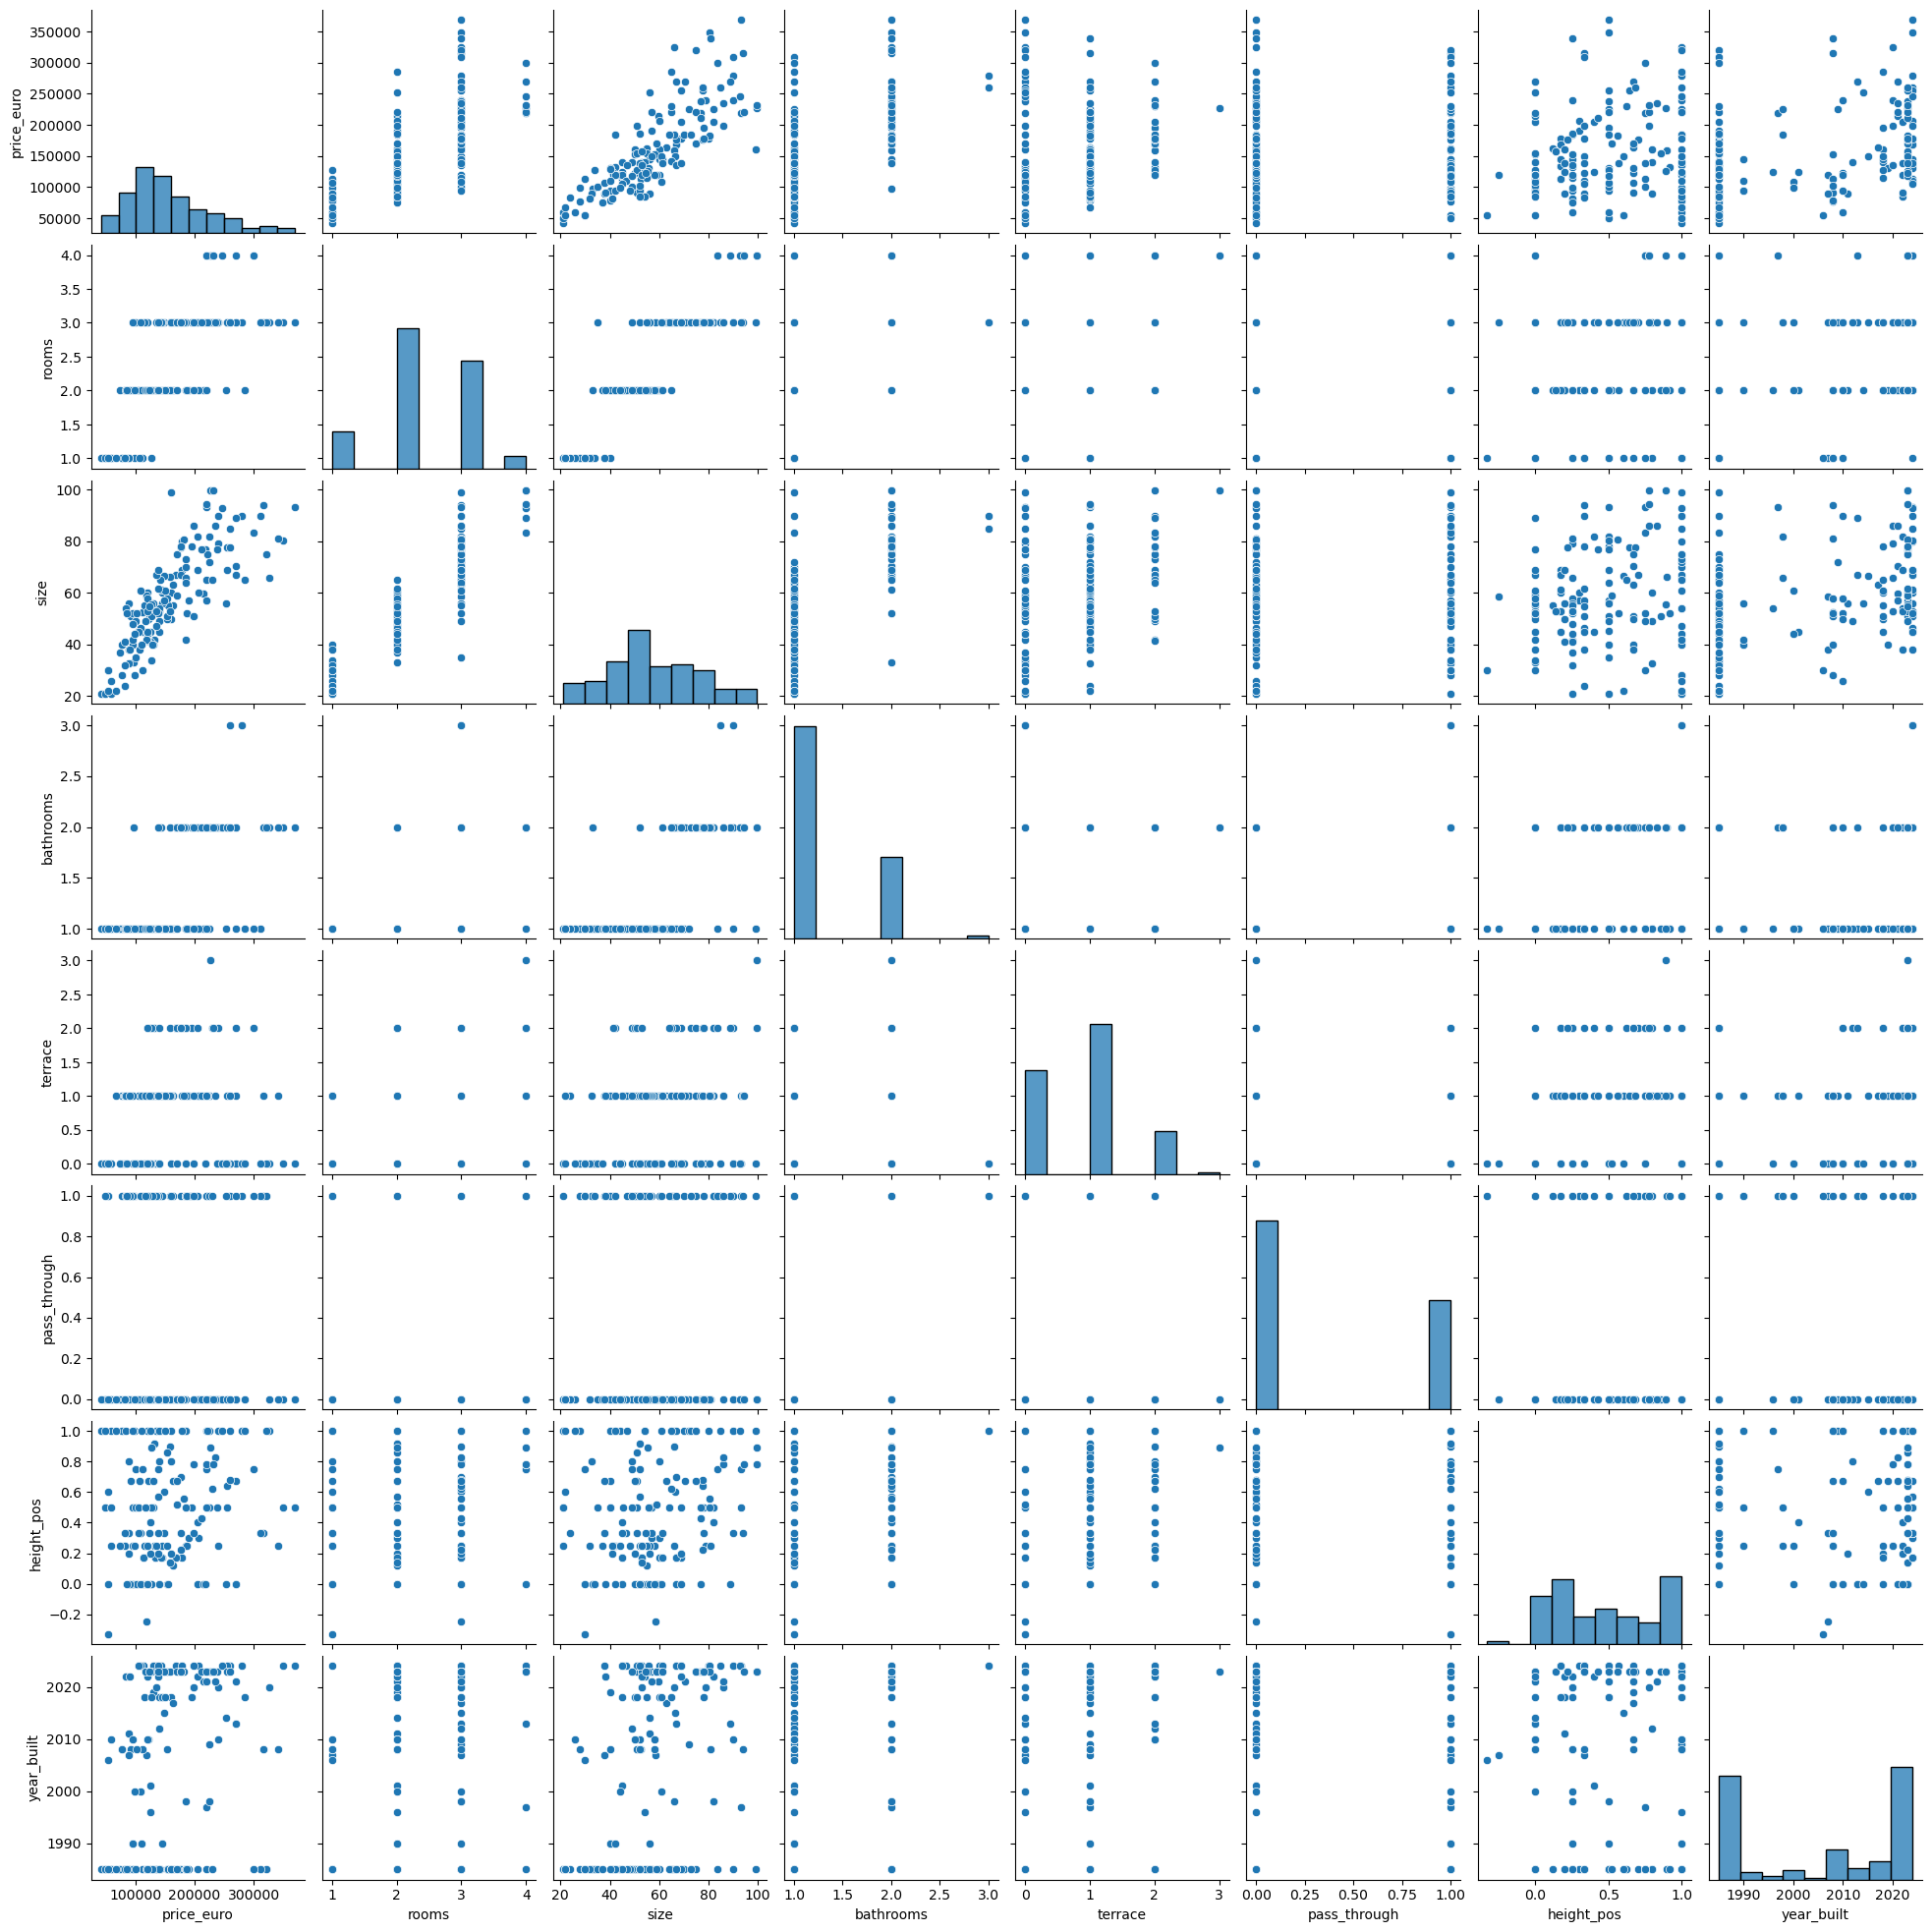

In [24]:
sns.pairplot(data)
plt.show()

<Axes: >

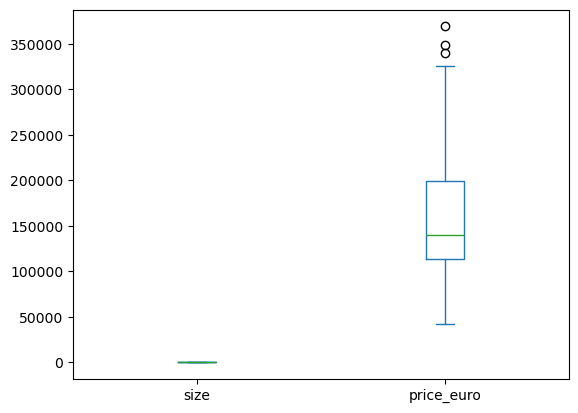

In [25]:
data[['size','price_euro']].plot(kind='box')

In [26]:
top_outliers = list(data['price_euro'].sort_values()[-3:].index)
data = data.drop(top_outliers)
len(data)

158

In [27]:
y = data.price_euro
X = data[['rooms', 'size', 'bathrooms', 'terrace', 'pass_through', 'finished', 'height_pos', 'neighbourhood', 'year_built', 'zone']]

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import GridSearchCV

In [30]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed")


Model Training Completed


In [31]:
y_pred = model.predict(X_test)

In [32]:
#  MODEL EVALUATION
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MODEL EVALUATION")
print(f"MAE  : {mae}")
print(f"MSE  : {mse}")
print(f"RMSE : {rmse}")
print(f"R2 Score : {r2}")


MODEL EVALUATION
MAE  : 28957.950937499998
MSE  : 1466207902.8685155
RMSE : 38291.09430231154
R2 Score : 0.5791544418238638


In [33]:
 # ACTUAL VS PREDICTED GRAPH
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\n==============================")
print("MODEL EVALUATION")
print("==============================")

print(f"MAE  : {mae}")
print(f"MSE  : {mse}")
print(f"RMSE : {rmse}")
print(f"R2 Score : {r2}")



MODEL EVALUATION
MAE  : 28957.950937499998
MSE  : 1466207902.8685155
RMSE : 38291.09430231154
R2 Score : 0.5791544418238638


In [34]:
# feature importance
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Important Features")
print(feature_importance.head(10))



Top Important Features
         Feature  Importance
1           size    0.755277
7  neighbourhood    0.076734
3        terrace    0.058050
6     height_pos    0.031780
8     year_built    0.030382
0          rooms    0.011171
4   pass_through    0.010399
5       finished    0.009122
9           zone    0.008688
2      bathrooms    0.008398


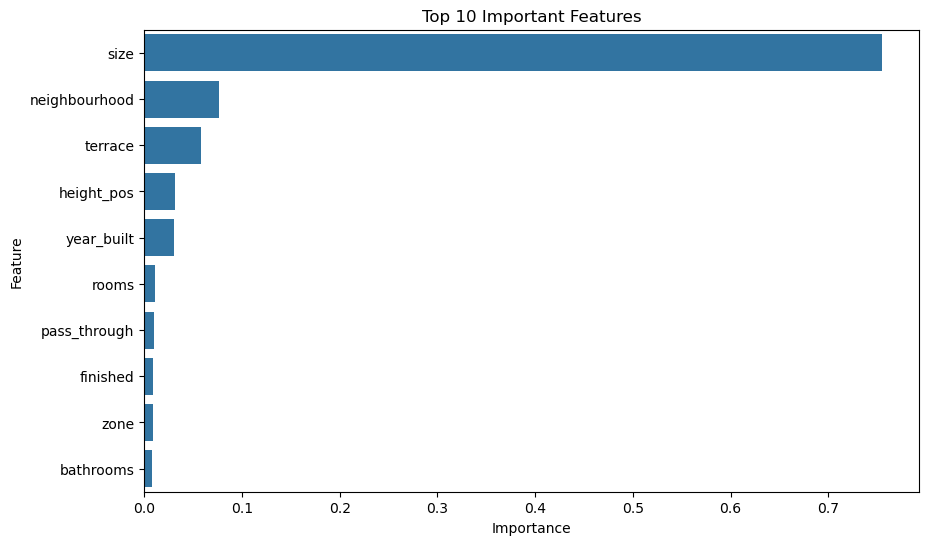

In [35]:
#feature importance visualization
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [36]:
# Select first tree from forest
single_tree = model.estimators_[0]

print("\nNumber of Trees:",
      len(model.estimators_))

print("Depth of Selected Tree:",
      single_tree.get_depth())


Number of Trees: 100
Depth of Selected Tree: 11


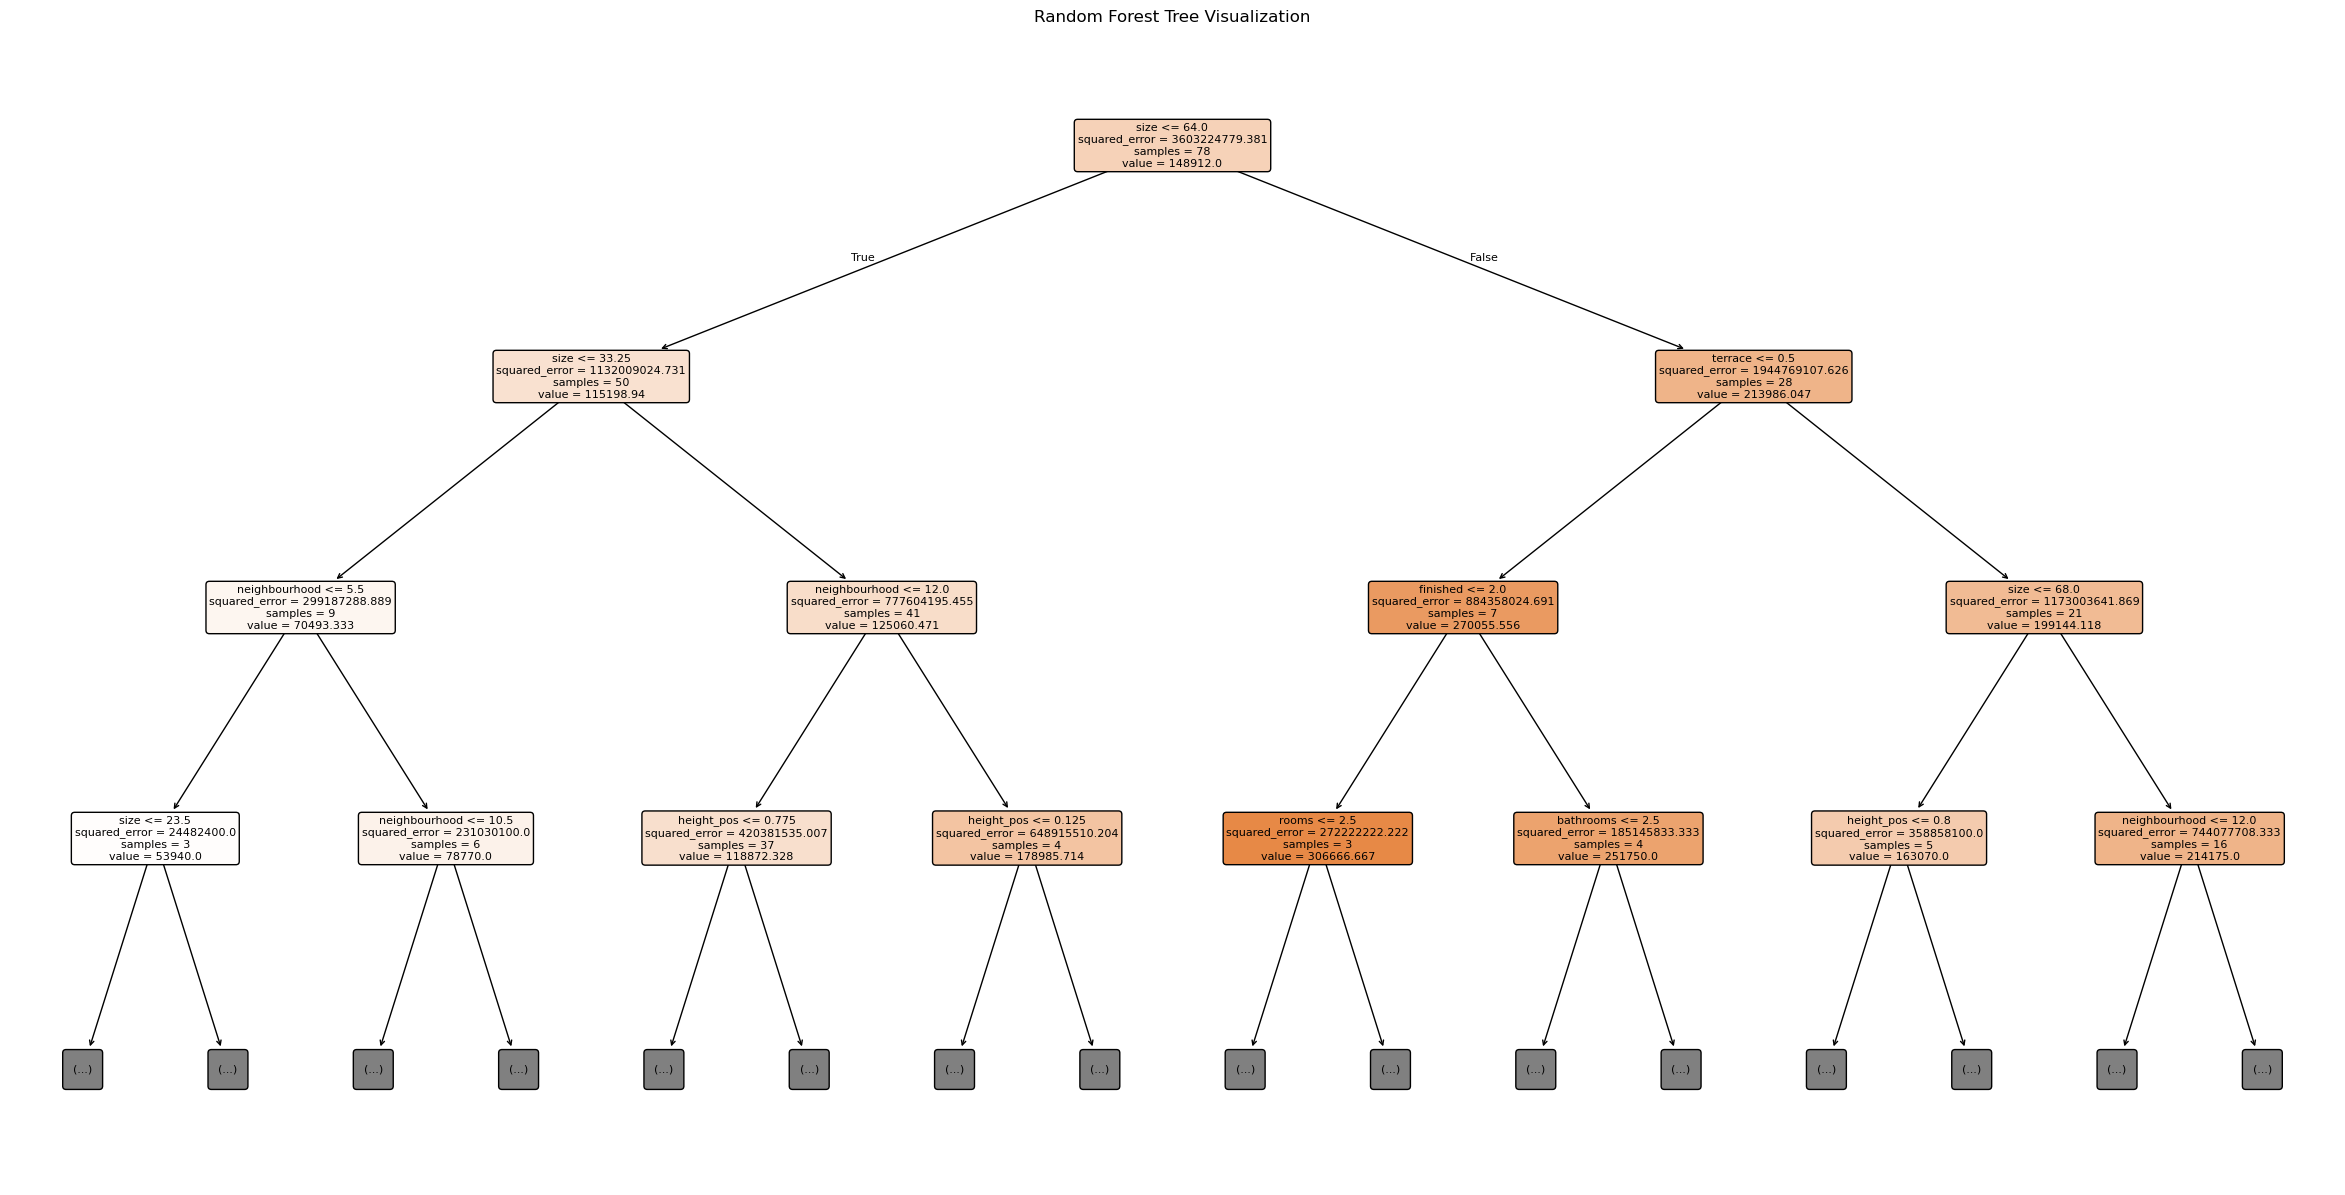

In [38]:
from sklearn import tree
plt.figure(figsize=(30,15))

tree.plot_tree(
    single_tree,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

plt.title("Random Forest Tree Visualization")

plt.show()


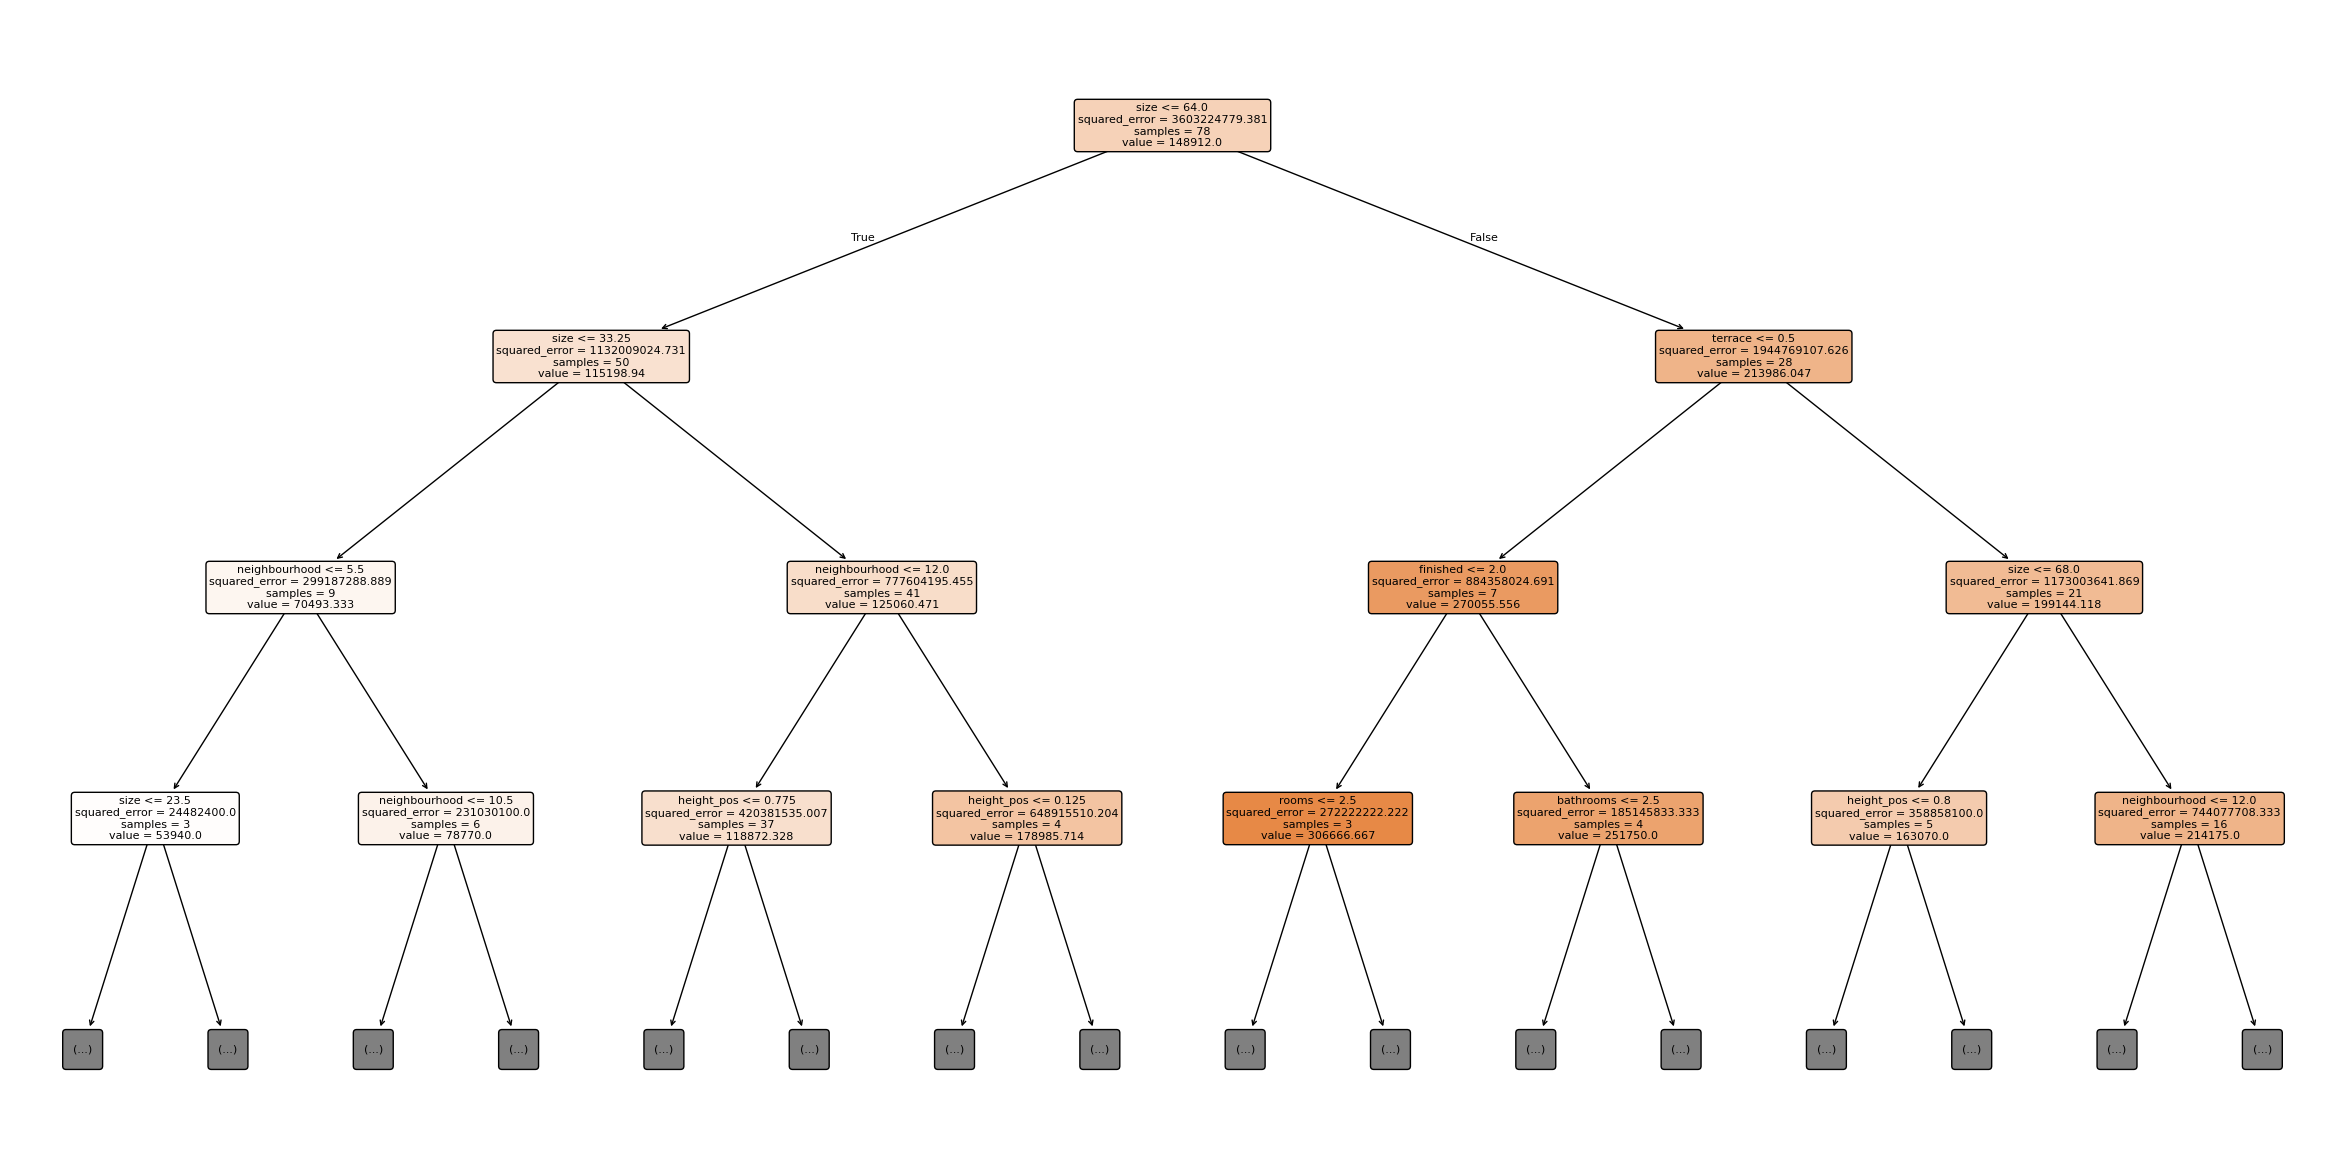


Tree Diagram Saved Successfully


In [39]:
# Save the tree diagram as an image
plt.figure(figsize=(30,15))

tree.plot_tree(
    single_tree,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

plt.savefig(
    "random_forest_tree.png"
)

plt.show()

print("\nTree Diagram Saved Successfully")

In [40]:
#  HYPERPARAMETER TUNING
parameters = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=parameters,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print("\nBest Parameters")
print(grid_search.best_params_)

print("\nBest R2 Score")
print(grid_search.best_score_)



Best Parameters
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

Best R2 Score
0.6422135034005801


In [41]:
best_model = grid_search.best_estimator_

best_model.fit(
    X_train,
    y_train
)

best_predictions = best_model.predict(
    X_test
)

best_r2 = r2_score(
    y_test,
    best_predictions
)

print("\nFinal R2 Score After Tuning")
print(best_r2)




Final R2 Score After Tuning
0.5920766131970143


In [43]:
# Save the best model using joblib

import joblib

joblib.dump(
    best_model,
    "house_price_model.pkl"
)

print("\nModel Saved Successfully")


Model Saved Successfully


In [44]:
#save columns
joblib.dump(
    X.columns.tolist(),
    "model_columns.pkl"
)

print("Column Names Saved Successfully")

Column Names Saved Successfully


In [45]:
#  SAMPLE PREDICTION
sample_data = X.iloc[0:1]

prediction = best_model.predict(
    sample_data
)

print("\nPredicted House Price")
print(prediction[0])



Predicted House Price
131369.3117210706
